In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Auto Sales data.csv.xlsx')
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2018-02-24,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2018-05-07,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2018-07-01,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2018-08-25,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,2018-10-28,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


### **How SALES is distributed for each DEALSIZE**

<Axes: xlabel='DEALSIZE', ylabel='SALES'>

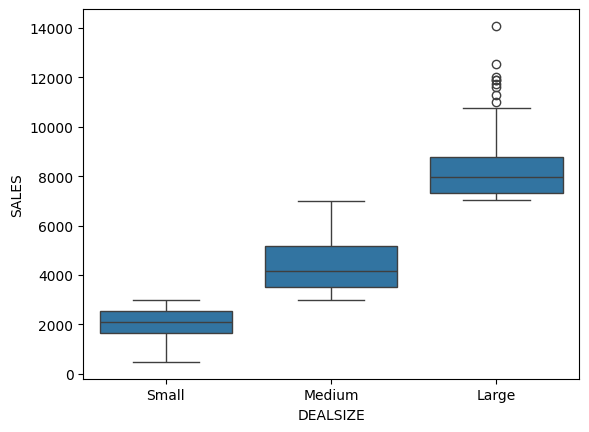

In [ ]:
sns.boxplot(data=df, x='DEALSIZE', y='SALES')

### **Distribution of deal size**

<Axes: xlabel='DEALSIZE', ylabel='count'>

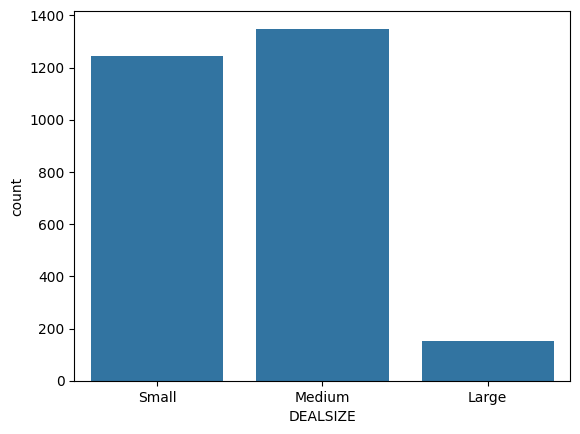

In [ ]:
sns.countplot(x='DEALSIZE',data=df)

### Analysis:

*   Medium-sized deals are the most common across the dataset.
*   The data is skewed toward small and medium deal sizes, implying that high-value (large) deals are relatively rare, possibly due to market affordability or product availability.



## **Average dealsize by country**



<Axes: xlabel='COUNTRY'>

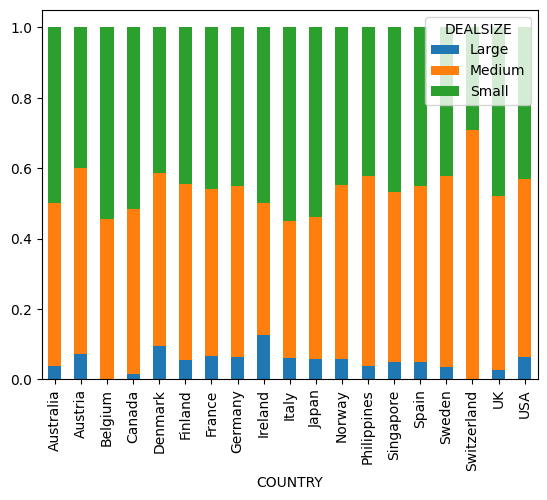

In [ ]:
df.groupby('COUNTRY')['DEALSIZE'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

### Analysis:


*  Switzerland, Denmark, and the USA report higher average sales in medium-sized deals, indicating a healthy mid-market car segment in those countries.
*   Ireland, Denmark, and Austria show the highest number of large deals, which could reflect a preference for premium vehicles or higher-value transactions in those markets.



### **DEALSIZE vs Product Line**

Text(0.5, 1.0, 'Deal Size by Product Line')

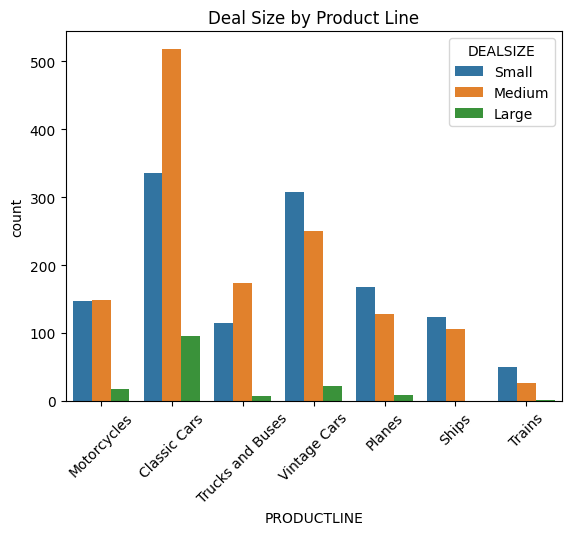

In [ ]:
sns.countplot(data=df, x='PRODUCTLINE', hue='DEALSIZE')
plt.xticks(rotation=45)
plt.title('Deal Size by Product Line')

### Analysis:


*  Classic Cars appear most frequently across small, medium, and large deal sizes, likely because they span a wide price range—from affordable models to high-value collectibles.

* Vintage Cars, Planes, and Motorcycles are dominated by small and medium deals, suggesting they are either lower in cost or typically purchased in smaller quantities.



In [ ]:
# Drop missing values
df_clean = df.dropna(subset=['DEALSIZE', 'SALES'])

# Create groups
small = df_clean[df_clean['DEALSIZE'] == 'Small']['SALES']
medium = df_clean[df_clean['DEALSIZE'] == 'Medium']['SALES']
large = df_clean[df_clean['DEALSIZE'] == 'Large']['SALES']

In [ ]:
result = f_oneway(small, medium, large)
print("F-statistic:", result.statistic)
print("P-value:", result.pvalue)


F-statistic: 4531.5809922995495
P-value: 0.0


In [ ]:
tukey_result = pairwise_tukeyhsd(
    endog=df_clean['SALES'],       # the numeric column
    groups=df_clean['DEALSIZE'],   # the categorical column
    alpha=0.05                     # significance level
)


In [ ]:
print(tukey_result.summary())


    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj   lower      upper    reject
-----------------------------------------------------------
 Large Medium -3885.8462   0.0 -4063.7763 -3707.9162   True
 Large  Small -6219.9804   0.0 -6398.6536 -6041.3072   True
Medium  Small -2334.1342   0.0  -2415.847 -2252.4213   True
-----------------------------------------------------------


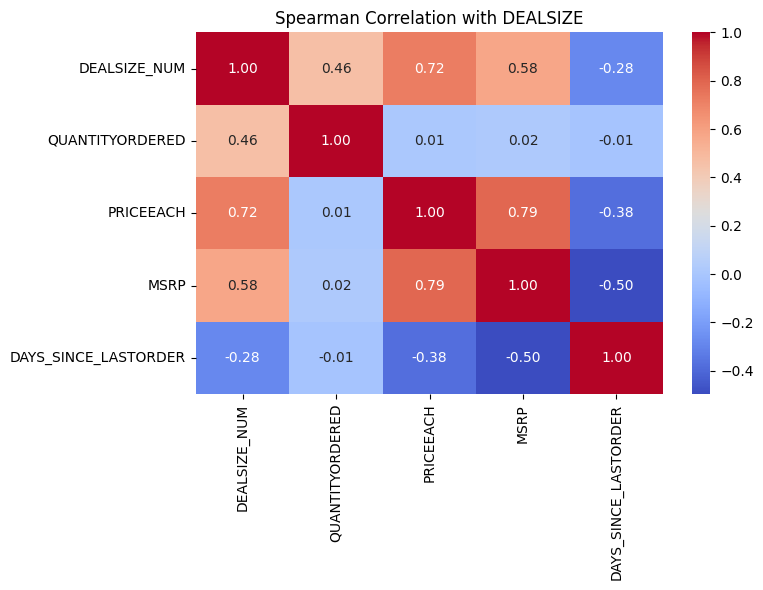

In [ ]:
df_clean['DEALSIZE_NUM'] = df_clean['DEALSIZE'].map({'Small': 0, 'Medium': 1, 'Large': 2})


correlation_features = ['DEALSIZE_NUM', 'QUANTITYORDERED', 'PRICEEACH', 'MSRP', 'DAYS_SINCE_LASTORDER']

dealsize_corr_matrix = df_clean[correlation_features].corr(method='spearman')


plt.figure(figsize=(8, 6))
sns.heatmap(dealsize_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation with DEALSIZE')
plt.tight_layout()


plt.savefig('dealsize_correlation_heatmap.png')
plt.show()